# Held-out validation of the allometric height model — `ovgu_bbox`

**The loop built here, entirely inside the Baumkataster:**

> split the `ovgu_bbox` registry trees into train and test → fit A, B on **train** →
> estimate heights on **test** from `CPA = π(Kronendurchmesser/2)²` → score against `Baumhoehe`
> on those same test trees.


In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from shapely.geometry import box
from pyproj import Transformer
from sklearn.model_selection import KFold, train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "test_notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import ALLOMETRIC_A, ALLOMETRIC_B, AREAS
from src.shadow.allometry import (
    BK_FIT_FILTER, bk_crown_area, fit_allometry, label_landuse,
    noise_ceiling, predict_height, score, smearing_factor,
)

AREA         = "ovgu_bbox"
REGISTRY     = ROOT / "references" / "Baeume_SFM_2026.gpkg"
PARK_NAME    = "Nordpark"          # matched against Objektbezeichnung
TEST_SIZE    = 0.30
N_FOLDS      = 5
RANDOM_STATE = 42

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## 1 · The population

Registry trees inside the `ovgu_bbox` extent, filtered with the **same** `BK_FIT_FILTER` that
produced the citywide n=84,081 fit — so every number below stays comparable to the quoted 0.531.

The park/street label comes from `Objektart lang` and needs no OSM fetch: `AMT 66` is the road
authority, and 30,231 of its 30,410 citywide rows carry `/SBG` (*Straßenbegleitgrün*) while no
`Öffentliches Grün` row does. `src/data_preprocessing/osm.py` only ever pulls `building` and `highway`.

In [2]:
bk = gpd.read_file(REGISTRY).query(BK_FIT_FILTER)

_t = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
_a = AREAS[AREA]
_w, _s = _t.transform(_a["west"], _a["south"])
_e, _n = _t.transform(_a["east"], _a["north"])

trees = bk[bk.geometry.within(box(_w, _s, _e, _n))].copy().reset_index(drop=True)

trees["cpa_m2"]  = bk_crown_area(trees["Kronendurchmesser"])
trees["landuse"] = label_landuse(trees)
trees["is_park"] = trees["Objektbezeichnung"].fillna("").str.contains(PARK_NAME)
# Three strata for reporting only. The large park is kept separate from the remaining green
# so that per-stratum accuracy is not dominated by it -- no split is defined on these labels.
trees["stratum"] = np.where(trees["is_park"], "park",
                     np.where(trees["landuse"] == "street", "street", "other green"))

print(f"{AREA}: {len(trees)} usable registry trees  (filter: {BK_FIT_FILTER})")
print(f"  area {(_e - _w):.0f} x {(_n - _s):.0f} m,  CRS {trees.crs.to_string()}\n")
print(trees.groupby("stratum").agg(
    n=("Baumhoehe", "size"),
    median_h_m=("Baumhoehe", "median"),
    median_crown_d_m=("Kronendurchmesser", "median"),
    median_cpa_m2=("cpa_m2", "median"),
).to_string())

ovgu_bbox: 1045 usable registry trees  (filter: Baumhoehe > 1 and Kronendurchmesser > 0.5)
  area 855 x 908 m,  CRS EPSG:25832

               n  median_h_m  median_crown_d_m  median_cpa_m2
stratum                                                      
other green   95      15.000             8.000         50.265
park         602      15.000             9.000         63.617
street       348       8.000             6.000         28.274


The bbox is one neighbourhood out of a city-wide registry, and the coefficients in `config.py` were
fitted on all of it. So the question that decides how far these results travel is whether this
neighbourhood is **representative** — if its trees are systematically larger or taller than the city
as a whole, a locally-fitted model is describing local trees, not Magdeburg trees.

In [3]:
city = bk.copy()
city["cpa_m2"]  = bk_crown_area(city["Kronendurchmesser"])
city["landuse"] = label_landuse(city)

def _profile(df, tag):
    out = {}
    for grp, d in [("all", df)] + sorted(df.groupby("landuse"), key=lambda kv: kv[0]):
        out[(grp, tag)] = {
            "n": len(d),
            "median_h_m": d["Baumhoehe"].median(),
            "median_crown_d_m": d["Kronendurchmesser"].median(),
            "median_cpa_m2": d["cpa_m2"].median(),
        }
    return out

prof = {**_profile(city, "city"), **_profile(trees, AREA)}
cmp_tbl = (pd.DataFrame(prof).T
             .rename_axis(index=["land use", "population"])
             .unstack()
             .swaplevel(axis=1)
             .sort_index(axis=1, level=0, ascending=False))
cmp_tbl[("city", "n")] = cmp_tbl[("city", "n")].astype(int)
cmp_tbl[(AREA, "n")]   = cmp_tbl[(AREA, "n")].astype(int)
print(cmp_tbl.to_string())

print(f"\n{AREA} holds {len(trees) / len(city) * 100:.1f}% of the {len(city):,} usable registry trees citywide.")
for k in ("all", "green", "street"):
    dh = prof[(k, AREA)]["median_h_m"] - prof[(k, "city")]["median_h_m"]
    dd = prof[(k, AREA)]["median_crown_d_m"] - prof[(k, "city")]["median_crown_d_m"]
    print(f"  {k:<7} median height {dh:+.1f} m, median crown diameter {dd:+.1f} m vs the city")

population ovgu_bbox                                             city                                          
                   n median_h_m median_crown_d_m median_cpa_m2      n median_h_m median_crown_d_m median_cpa_m2
land use                                                                                                       
all             1045     12.000            8.000        50.265  84081     11.000            6.000        28.274
green            696     15.000            9.000        63.617  53947     12.000            6.000        28.274
street           349      8.000            6.000        28.274  30134      9.000            6.000        28.274

ovgu_bbox holds 1.2% of the 84,081 usable registry trees citywide.
  all     median height +1.0 m, median crown diameter +2.0 m vs the city
  green   median height +3.0 m, median crown diameter +3.0 m vs the city
  street  median height -1.0 m, median crown diameter +0.0 m vs the city


## 2 · Split A — a plain 70/30 train/test split

Stratified by park / street / other green so the test set keeps the same composition as the whole,
which matters here because one park is 58 % of the data.

Fit on train, estimate heights on test, score against the test trees' own `Baumhoehe`.

In [4]:
train, test = train_test_split(
    trees, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=trees["stratum"]
)
assert not (set(train.index) & set(test.index)), "train/test overlap"

A, B, n_fit = fit_allometry(train["cpa_m2"], train["Baumhoehe"])
base = train["Baumhoehe"].mean()          # fixed baseline, from TRAIN only
print(f"train n={n_fit}  ->  A={A:.3f}  B={B:.3f}    (config: A={ALLOMETRIC_A}, B={ALLOMETRIC_B})")
print(f"train mean height = {base:.2f} m   Duan smearing factor = {smearing_factor(train['cpa_m2'], train['Baumhoehe'], A, B):.4f}")
print("  (smearing would convert the median predictor to a mean predictor -- reported, not applied)\n")

rows = [{"subset": "TEST all", **score(test["Baumhoehe"], predict_height(test["cpa_m2"], A, B), base)}]
for k, d in test.groupby("stratum"):
    rows.append({"subset": f"TEST {k}", **score(d["Baumhoehe"], predict_height(d["cpa_m2"], A, B), base)})
split_a = pd.DataFrame(rows).set_index("subset")
print(split_a.to_string())

train n=731  ->  A=1.181  B=0.349    (config: A=1.317, B=0.318)
train mean height = 13.13 m   Duan smearing factor = 1.0488
  (smearing would convert the median predictor to a mean predictor -- reported, not applied)

                    n  bias_m  MAE_m  RMSE_m  r2_ln  r2_m  median_ratio
subset                                                                 
TEST all          314  -0.486  3.252   4.285  0.651 0.582         1.055
TEST other green   28  -0.578  2.926   3.393  0.409 0.379         0.995
TEST park         181  -1.139  3.583   4.847  0.666 0.553         0.969
TEST street       105   0.663  2.770   3.366  0.535 0.684         1.150


## 3 · Split B — 5-fold cross-validation  ·  **the headline**

Every tree gets a prediction from a model that never saw it, so all 1,045 are scored out-of-fold
rather than only the 314 in Split A's test set.

The per-fold coefficient table is the check that matters: if A and B swing wildly across folds, a
single 70/30 split was luck. If they are stable, the model is identified by this data.

In [5]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof = np.full(len(trees), np.nan)
fold_rows = []

for i, (itr, ite) in enumerate(kf.split(trees), start=1):
    assert not (set(itr) & set(ite)), f"fold {i}: train/test overlap"
    a, b, n = fit_allometry(trees["cpa_m2"].iloc[itr], trees["Baumhoehe"].iloc[itr])
    oof[ite] = predict_height(trees["cpa_m2"].iloc[ite], a, b)
    fold_rows.append({"fold": i, "n_train": n, "n_test": len(ite), "A": a, "B": b})

assert not np.isnan(oof).any(), "some tree never received an out-of-fold prediction"
print(pd.DataFrame(fold_rows).set_index("fold").to_string())
print(f"\nA spread: {min(r['A'] for r in fold_rows):.3f} - {max(r['A'] for r in fold_rows):.3f}"
      f"   B spread: {min(r['B'] for r in fold_rows):.3f} - {max(r['B'] for r in fold_rows):.3f}")

      n_train  n_test     A     B
fold                             
1         836     209 1.174 0.351
2         836     209 1.199 0.343
3         836     209 1.185 0.348
4         836     209 1.128 0.358
5         836     209 1.154 0.352

A spread: 1.128 - 1.199   B spread: 0.343 - 0.358


In [6]:
base_all = trees["Baumhoehe"].mean()
rows = [{"subset": "pooled OOF", **score(trees["Baumhoehe"], oof, base_all)}]
for k, idx in trees.groupby("stratum").groups.items():
    rows.append({"subset": f"OOF {k}", **score(trees.loc[idx, "Baumhoehe"], oof[trees.index.get_indexer(idx)], base_all)})
split_b = pd.DataFrame(rows).set_index("subset")
print(split_b.to_string())

                    n  bias_m  MAE_m  RMSE_m  r2_ln  r2_m  median_ratio
subset                                                                 
pooled OOF       1045  -0.624  3.066   4.044  0.661 0.604         1.006
OOF other green    95  -0.130  2.563   3.100  0.623 0.564         1.037
OOF park          602  -1.307  3.330   4.482  0.676 0.588         0.935
OOF street        348   0.424  2.746   3.426  0.531 0.650         1.144


## 4 · Error in metres, by how tall the tree actually is

R² is a single number over a population; it does not say *how wrong the height is*, which is what
the shadow model downstream consumes. Shadow length scales as `height / tan(sun elevation)`, so a
metre of height error is a metre-scale error in the cast shadow.

Binning the out-of-fold predictions by **observed** height gives the decision-relevant view.

In [7]:
oof_df = trees[["Baumhoehe", "stratum"]].copy()
oof_df["pred_m"] = oof
oof_df["err_m"]  = oof_df["pred_m"] - oof_df["Baumhoehe"]
oof_df["abs_pct"] = (oof_df["err_m"] / oof_df["Baumhoehe"]).abs() * 100

BANDS = [0, 6, 10, 14, 18, 22, 40]
oof_df["band"] = pd.cut(oof_df["Baumhoehe"], BANDS, right=False)

by_band = oof_df.groupby("band", observed=True).agg(
    n=("err_m", "size"),
    median_observed_m=("Baumhoehe", "median"),
    median_predicted_m=("pred_m", "median"),
    bias_m=("err_m", "mean"),
    MAE_m=("err_m", lambda s: s.abs().mean()),
    median_abs_pct=("abs_pct", "median"),
)
print(by_band.to_string())

tall = oof_df[oof_df["Baumhoehe"] >= 22]
print(f"\nPredictions span {oof_df['pred_m'].min():.1f}-{oof_df['pred_m'].max():.1f} m; "
      f"observations span {oof_df['Baumhoehe'].min():.0f}-{oof_df['Baumhoehe'].max():.0f} m.")
print(f"Trees >= 22 m (n={len(tall)}) are under-predicted by {-tall['err_m'].mean():.1f} m on average,")
print(f"which shortens their modelled shadow by about {100 * -tall['err_m'].mean() / tall['Baumhoehe'].mean():.0f}%.")

            n  median_observed_m  median_predicted_m  bias_m  MAE_m  median_abs_pct
band                                                                               
[0, 6)    107              4.000               5.555   1.141  1.803          29.145
[6, 10)   290              8.000               9.223   2.037  2.356          30.522
[10, 14)  160             12.000              12.580   0.814  2.128          15.354
[14, 18)  196             16.000              13.882  -1.205  2.745          16.516
[18, 22)  159             20.000              15.973  -2.670  3.692          18.016
[22, 40)  133             24.000              17.940  -6.271  6.482          23.725

Predictions span 2.8-29.2 m; observations span 3-30 m.
Trees >= 22 m (n=133) are under-predicted by 6.3 m on average,
which shortens their modelled shadow by about 26%.


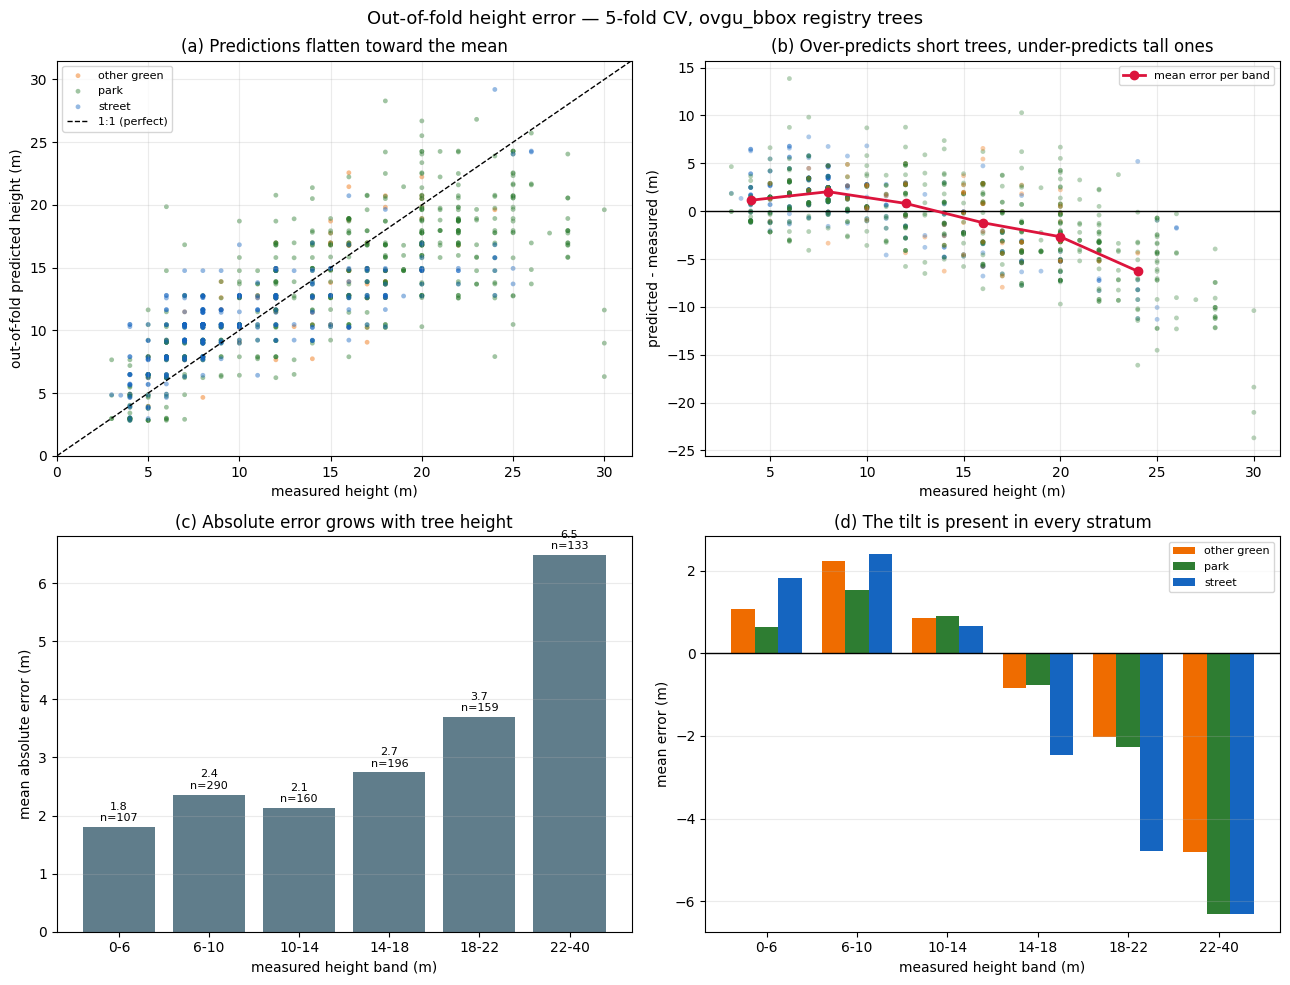

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
COL = {"park": "#2e7d32", "street": "#1565c0", "other green": "#ef6c00"}

# (a) predicted vs observed -- the whole story in one panel
a = ax[0, 0]
for k, d in oof_df.groupby("stratum"):
    a.scatter(d["Baumhoehe"], d["pred_m"], s=12, alpha=0.45, color=COL[k], label=k, edgecolors="none")
lim = [0, max(oof_df["Baumhoehe"].max(), oof_df["pred_m"].max()) * 1.05]
a.plot(lim, lim, "k--", lw=1, label="1:1 (perfect)")
a.set(xlim=lim, ylim=lim, xlabel="measured height (m)", ylabel="out-of-fold predicted height (m)",
      title="(a) Predictions flatten toward the mean")
a.legend(fontsize=8, loc="upper left"); a.grid(alpha=.25)

# (b) residual vs observed, with the binned mean drawn through it
a = ax[0, 1]
a.axhline(0, color="k", lw=1)
a.scatter(oof_df["Baumhoehe"], oof_df["err_m"], s=12, alpha=0.35,
          c=[COL[k] for k in oof_df["stratum"]], edgecolors="none")
ctr = by_band["median_observed_m"].to_numpy()
a.plot(ctr, by_band["bias_m"].to_numpy(), "o-", color="crimson", lw=2, ms=6, label="mean error per band")
a.set(xlabel="measured height (m)", ylabel="predicted - measured (m)",
      title="(b) Over-predicts short trees, under-predicts tall ones")
a.legend(fontsize=8); a.grid(alpha=.25)

# (c) how big is the error, in metres, per band
a = ax[1, 0]
lbl = [f"{int(i.left)}-{int(i.right)}" for i in by_band.index]
a.bar(lbl, by_band["MAE_m"], color="#607d8b")
for i, (v, n) in enumerate(zip(by_band["MAE_m"], by_band["n"])):
    a.text(i, v + .1, f"{v:.1f}\nn={n}", ha="center", fontsize=8)
a.set(xlabel="measured height band (m)", ylabel="mean absolute error (m)",
      title="(c) Absolute error grows with tree height")
a.grid(alpha=.25, axis="y")

# (d) does the park/street gap explain it, or is it on top of it?
a = ax[1, 1]
piv = oof_df.pivot_table(index="band", columns="stratum", values="err_m", aggfunc="mean", observed=True)
x = np.arange(len(piv)); w = 0.26
for i, k in enumerate(piv.columns):
    a.bar(x + (i - 1) * w, piv[k], w, color=COL[k], label=k)
a.axhline(0, color="k", lw=1)
a.set_xticks(x, [f"{int(i.left)}-{int(i.right)}" for i in piv.index])
a.set(xlabel="measured height band (m)", ylabel="mean error (m)",
      title="(d) The tilt is present in every stratum")
a.legend(fontsize=8); a.grid(alpha=.25, axis="y")

fig.suptitle("Out-of-fold height error — 5-fold CV, ovgu_bbox registry trees", fontsize=13)
fig.tight_layout()
plt.show()

## 5 · What the splits actually look like

The trees are a spatial population, so the honest way to check a split is to draw it. Both panels
show the same 1,045 trees on the same extent.

Both splits assign trees at random, which the maps make plain: test points sit interleaved with
training points along the same street rows and inside the same park. Since neighbouring trees share
species, planting cohort and management, that is a mild optimism in every score above — worth seeing
rather than asserting.

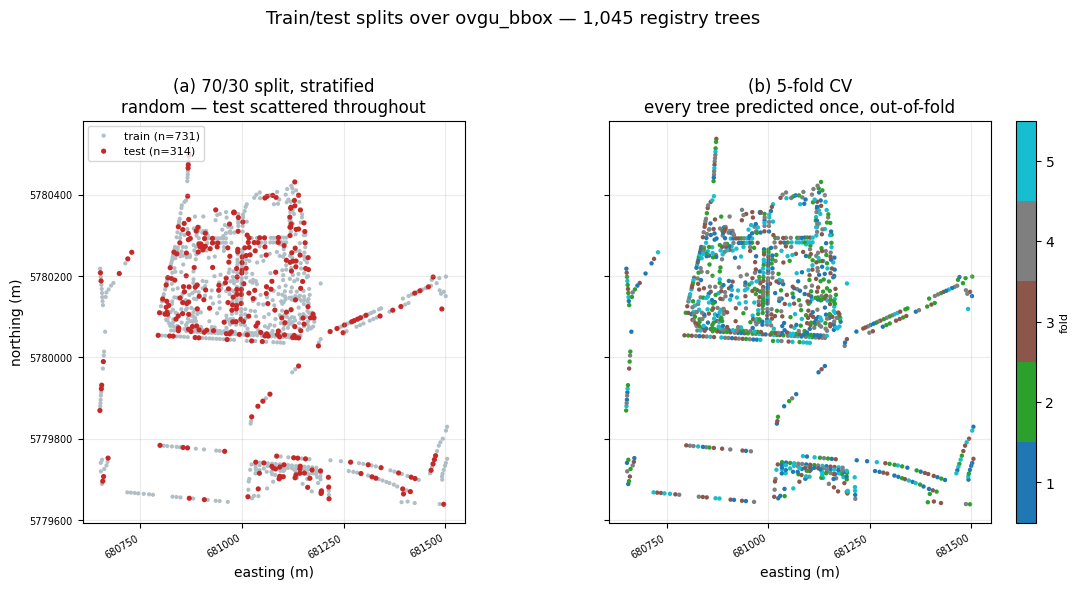

In [9]:
xy = np.c_[trees.geometry.x, trees.geometry.y]
fig, ax = plt.subplots(1, 2, figsize=(11.5, 5.6), sharex=True, sharey=True)

# (a) 70/30
is_test = trees.index.isin(test.index)
ax[0].scatter(*xy[~is_test].T, s=9, c="#b0bec5", label=f"train (n={(~is_test).sum()})", edgecolors="none")
ax[0].scatter(*xy[is_test].T, s=14, c="#c62828", label=f"test (n={is_test.sum()})", edgecolors="none")
ax[0].set_title(f"(a) 70/30 split, stratified\nrandom — test scattered throughout")
ax[0].legend(fontsize=8, loc="upper left")

# (b) folds
fold_id = np.empty(len(trees), dtype=int)
for i, (_, ite) in enumerate(kf.split(trees), start=1):
    fold_id[ite] = i
cmap = plt.get_cmap("tab10", N_FOLDS)
sc = ax[1].scatter(*xy.T, s=10, c=fold_id, cmap=cmap, vmin=.5, vmax=N_FOLDS + .5, edgecolors="none")
ax[1].set_title(f"(b) {N_FOLDS}-fold CV\nevery tree predicted once, out-of-fold")
cb = fig.colorbar(sc, ax=ax[1], ticks=range(1, N_FOLDS + 1), fraction=.046)
cb.set_label("fold", fontsize=8)

for a in ax:
    a.set_aspect("equal"); a.grid(alpha=.25); a.set_xlabel("easting (m)")
    # Plain metre labels: UTM easting is 6 digits, so thin the ticks and rotate rather
    # than let matplotlib fall back to a shared offset that prints only one label.
    a.xaxis.set_major_locator(plt.MaxNLocator(4))
    a.yaxis.set_major_locator(plt.MaxNLocator(5))
    a.ticklabel_format(style="plain", useOffset=False)
    a.tick_params(labelsize=7); plt.setp(a.get_xticklabels(), rotation=30, ha="right")
ax[0].set_ylabel("northing (m)")
fig.suptitle("Train/test splits over ovgu_bbox — 1,045 registry trees", fontsize=13, y=1.04)
fig.tight_layout()
plt.show()